# GEOG 5545 MVP 1

The max-p-regions problem involves the aggregation of n areas into an unknown maximum number of homogeneous regions, while ensuring that each region is contiguous and satisfies a minimum threshold value imposed on a predefined spatially extensive attribute. This class is designed to solve the max-p-regions problem using a exact optimization approach with mixed-integer linear programing (MILP) solvers.

In [1]:
from maxp_exact import MaxPExact, MaxPConfig
import numpy as np
from copy import deepcopy
import libpysal
import geopandas as gpd

## Test Formulations on Small Instance

### Define a Max-P-Region Problem

Fenoarivobe District, Madagascar

Initialize 2 identical max-p-regions instances from vectors

In [2]:
base_mg = MaxPExact(
    adj_mat = np.array([
        [0, 1, 1, 1, 0, 0, 1, 0, 1, 1],
        [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
        [1, 0, 0, 1, 0, 1, 1, 1, 0, 0],
        [1, 0, 1, 0, 0, 0, 1, 1, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
        [1, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 1, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
    ]),

    sim_mat = np.array([
        [0.0, 10.381, 12.62, 19.702, 0.0, 0.0, 74.403, 0.0, 40.952, 40.954],
        [10.381, 0.0, 0.0, 0.0, 23.433, 0.0, 0.0, 0.0, 0.0, 40.804],
        [12.62, 0.0, 0.0, 17.381, 0.0, 44.155, 31.795, 40.779, 0.0, 0.0],
        [19.702, 0.0, 17.381, 0.0, 0.0, 0.0, 39.056, 15.545, 0.0, 0.0],
        [0.0, 23.433, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 44.155, 0.0, 0.0, 0.0, 0.0, 8.958, 0.0, 0.0],
        [74.403, 0.0, 31.795, 39.056, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 40.779, 15.545, 0.0, 8.958, 0.0, 0.0, 0.0, 0.0],
        [40.952, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        [40.954, 40.804, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    ]),

    spatial_attr = np.array([28780, 37650, 31150, 22610, 11490, 14840, 6280, 9450, 12700, 10650]),

    threshold = 20000,

    dissimilarity = True
)

strong_mg = deepcopy(base_mg)

### Create Max-P Configuration Objects and Construct MILP problems

In [2]:
base_config = MaxPConfig()
strong_config = MaxPConfig(bound_num_regions=True, bound_contiguity=True, merge_leaves=True, preassign_roots=True, exclude_roots=True, max_attr_for_root=True, min_adj_order=True, sort_region_roots=True)

In [4]:
base_mg.construct(base_config)
strong_mg.construct(strong_config)

### Solve both instances

In [5]:
%%time
base_mg.solve(600)

CPU times: total: 2min 57s
Wall time: 3min 4s


In [6]:
%%time
strong_mg.solve(600)

CPU times: total: 62.5 ms
Wall time: 62.2 ms


## Test a Real World Instance
Mexico, this is one of the examples instances used for the pysal heuristic documentation

In [4]:
# Import data
pth = libpysal.examples.get_path("mexicojoin.shp")
MEXICO = gpd.read_file(pth)

# Assign count, weight to provide a sort order
MEXICO["count"] = 1000*np.ones(32).astype(int) + np.arange(32).astype(int)

# Create weights object
weights = libpysal.weights.Queen.from_dataframe(MEXICO)

C:\Users\aoheg\AppData\Local\Temp\ipykernel_24076\2058208018.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  weights = libpysal.weights.Queen.from_dataframe(MEXICO)


### Define and Construct Problem Instance from Geopandas

In [5]:
# Dissimilarity attribute list
mxgdp_years = [str(x) for x in range(1940, 2010, 10)]
dissim_attr = [f"PCGDP{year}" for year in mxgdp_years[1:]]

# Define and construct instance
mx_test = MaxPExact.from_gdf(MEXICO, weights, dissim_attr, "count", 3000)
mx_test.construct(strong_config)

### Solve Mexico Instance

In [6]:
%%time
mx_test.solve(3600*24)

CPU times: total: 15min 53s
Wall time: 17min 23s


<Axes: >

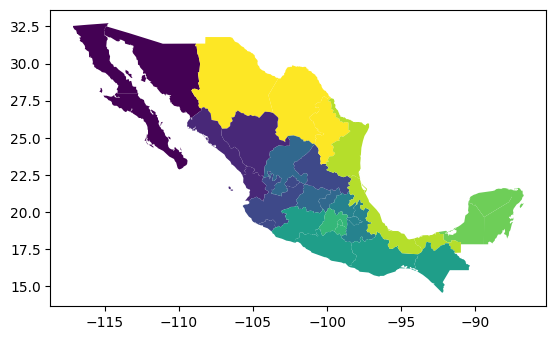

In [7]:
MEXICO['region'] = mx_test.regions
MEXICO.plot(column='region')